In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [61]:
# Load data
df = pd.read_csv('kozhikode properties.csv')
print(f"\nColumns: {list(df.columns)}")
df.head()


Columns: ['locality', 'apartment_type', 'bhk', 'floor', 'rent']


,locality,apartment_type,bhk,floor,rent
0,Bilathikulam,Flat,1,4.0,9000
1,Chevayur,Apartment,2,7.0,19500
2,Mavoor Road,House,3,NaN,39500
3,Feroke,Flat,2,8.0,12000
4,Koyilandy Road,House,2,NaN,19000


In [62]:
# Data summary
print("Dataset Statistics:")
print("=" * 60)
print(f"Total Properties: {len(df):,}")
print(f"Localities: {df['locality'].nunique()}")
print(f"\nProperty Type Distribution:")
print(df['apartment_type'].value_counts())
print(f"\nBHK Distribution:")
print(df['bhk'].value_counts().sort_index())
print(f"\nRent Statistics:")
print(df['rent'].describe())

Dataset Statistics:
Total Properties: 10,000
Localities: 26

Property Type Distribution:
apartment_type
Apartment    4568
Flat         3461
Villa        1199
House         772
Name: count, dtype: int64

BHK Distribution:
bhk
1    2502
2    4453
3    2566
4     479
Name: count, dtype: int64

Rent Statistics:
count    10000.000000
mean     20169.550000
std      10378.802906
min       5000.000000
25%      12500.000000
50%      18000.000000
75%      25500.000000
max      86000.000000
Name: rent, dtype: float64


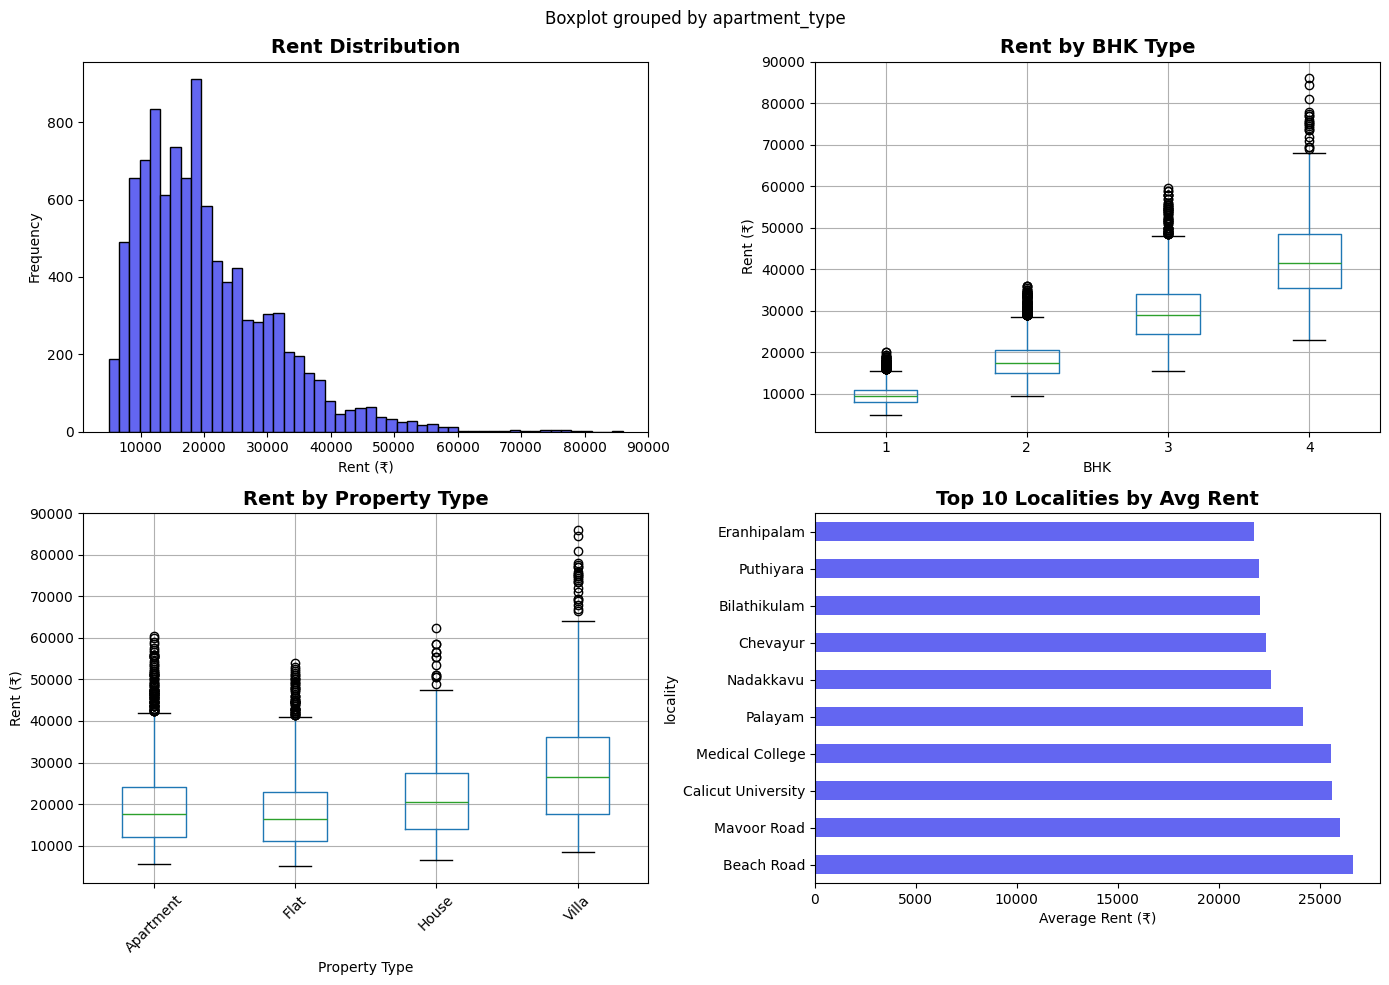

In [63]:
# Visualize rent distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rent distribution
df['rent'].plot(kind='hist', bins=50, ax=axes[0,0], color='#6366f1', edgecolor='black')
axes[0,0].set_title('Rent Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Rent (₹)')
axes[0,0].set_ylabel('Frequency')

# Rent by BHK
df.boxplot(column='rent', by='bhk', ax=axes[0,1])
axes[0,1].set_title('Rent by BHK Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('BHK')
axes[0,1].set_ylabel('Rent (₹)')

# Rent by apartment type
df.boxplot(column='rent', by='apartment_type', ax=axes[1,0])
axes[1,0].set_title('Rent by Property Type', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Property Type')
axes[1,0].set_ylabel('Rent (₹)')
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)

# Top 10 localities by average rent
top_localities = df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(10)
top_localities.plot(kind='barh', ax=axes[1,1], color='#6366f1')
axes[1,1].set_title('Top 10 Localities by Avg Rent', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Average Rent (₹)')

plt.tight_layout()
plt.show()

In [64]:
# Encode categorical variables
locality_map = {loc: idx for idx, loc in enumerate(sorted(df['locality'].unique()))}
locality_map['unknown'] = len(locality_map)

apartment_map = {apt: idx for idx, apt in enumerate(sorted(df['apartment_type'].unique()))}

df['locality_code'] = df['locality'].map(locality_map)
df['apartment_code'] = df['apartment_type'].map(apartment_map)

# Calculate averages for each feature
locality_avg = df.groupby('locality')['rent'].mean().to_dict()
bhk_avg = df.groupby('bhk')['rent'].mean().to_dict()
apartment_avg = df.groupby('apartment_type')['rent'].mean().to_dict()
global_avg = df['rent'].mean()

# Add aggregated features
df['locality_avg'] = df['locality'].map(locality_avg)
df['bhk_avg'] = df['bhk'].map(bhk_avg)
df['apartment_avg'] = df['apartment_type'].map(apartment_avg)

# Fill NaN floors with 0
df['floor'] = df['floor'].fillna(0).astype(int)

print("✓ Feature engineering complete")
print(f"\nEncoded mappings created:")
print(f"  - {len(locality_map)} localities")
print(f"  - {len(apartment_map)} property types")
print(f"\nAggregated features added:")
print(f"  - locality_avg, bhk_avg, apartment_avg")

✓ Feature engineering complete

Encoded mappings created:
  - 27 localities
  - 4 property types

Aggregated features added:
  - locality_avg, bhk_avg, apartment_avg


In [65]:
# Prepare feature matrix
feature_cols = ['bhk', 'locality_code', 'apartment_code', 'floor', 'locality_avg', 'bhk_avg', 'apartment_avg']
X = df[feature_cols]
y = df['rent']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train):,} properties")
print(f"Test set: {len(X_test):,} properties")

Training set: 8,000 properties
Test set: 2,000 properties


In [86]:
# Train GradientBoosting model 
model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    verbose=1
)

model.fit(X_train, y_train)


      Iter       Train Loss      OOB Improve   Remaining Time 
         1    87512016.2313    19786461.1535            0.89s
         2    72306266.5120    16008807.6469            0.73s
         3    60529712.8074    15521097.8806            0.71s
         4    49604215.6514     6926856.1755            0.69s
         5    41748816.3647     9997560.8219            0.68s
         6    35163082.2432     7806311.7546            0.65s
         7    29579764.6799     6198612.5022            0.63s
         8    24988650.4896     4810785.2359            0.60s
         9    21084549.8953     3755304.0495            0.58s
        10    17805864.3935     2750444.1976            0.56s
        20     4511850.6132      970904.5862            0.52s
        30     2063087.1784       22573.4030            0.45s
        40     1479456.9548       42207.2738            0.39s
        50     1244764.6113       23050.3487            0.32s
        60     1170409.0407        8126.6396            0.26s
       

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [87]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("MODEL PERFORMANCE")
print("=" * 60)
print(f"\nTest Set Metrics:")
print(f"  MAE (Mean Absolute Error): ₹{mae:,.0f}")
print(f"  R² Score: {r2:.4f}")
print(f"  MAPE: {mape:.2f}%")
print(f"\n5-Fold Cross-Validation:")
print(f"  Mean R²: {cv_scores.mean():.4f}")
print(f"  Std R²: {cv_scores.std():.4f}")
print(f"\n✓ Low std deviation means NO OVERFITTING!")

      Iter       Train Loss      OOB Improve   Remaining Time 
         1    87258712.8719    19867529.7277            1.09s
         2    72507752.5952    17512119.3054            0.97s
         3    61246000.9413    17801652.1296            0.87s
         4    50087006.3829     5966036.3759            0.82s
         5    41363361.6519     6892612.8799            0.78s
         6    34618440.1238     6947088.2352            0.77s
         7    29515787.2506     7755969.0565            0.73s
         8    24816847.9141     4565616.6521            0.70s
         9    21217279.3265     4790494.6862            0.69s
        10    17552709.4093     1246749.2129            0.67s
        20     4589551.0897      575060.8287            0.58s
        30     2082262.5212      261302.1539            0.50s
        40     1475880.7160       63366.7060            0.45s
        50     1279619.6938      -57449.5681            0.37s
        60     1203620.0904      130972.8199            0.29s
       


FEATURE IMPORTANCE:
          Feature  Importance
0             bhk    0.480644
5         bhk_avg    0.246079
4    locality_avg    0.151967
6   apartment_avg    0.065840
2  apartment_code    0.053025
3           floor    0.001778
1   locality_code    0.000667


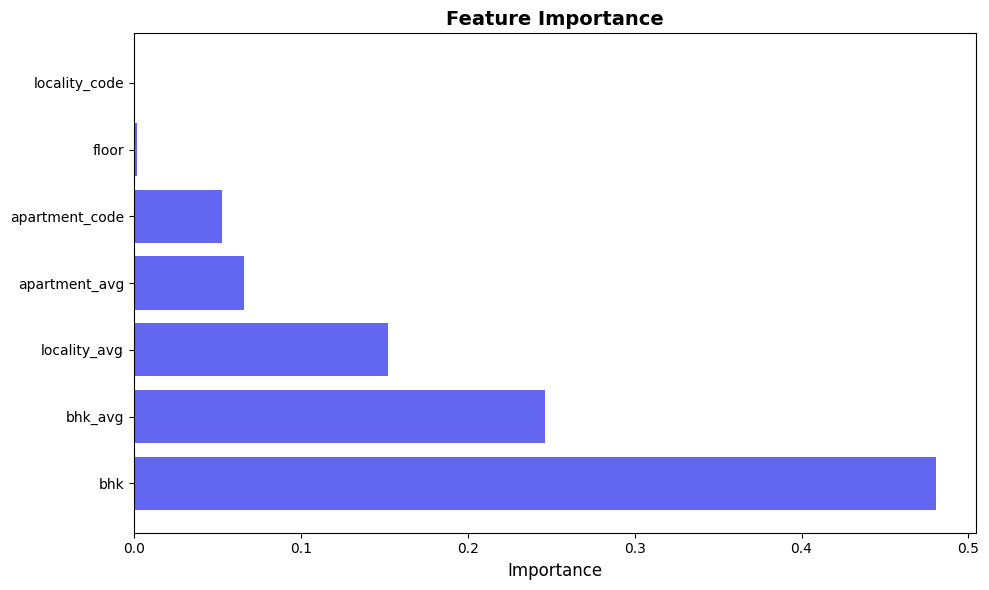

In [68]:
# Feature importance
importances = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nFEATURE IMPORTANCE:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#6366f1')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

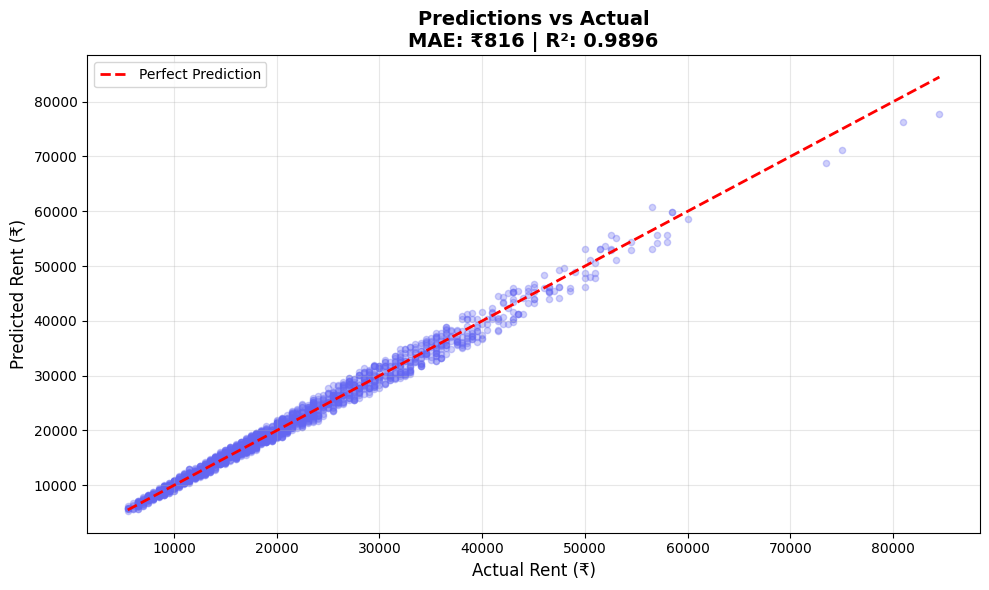

In [69]:
# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=20, color='#6366f1')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rent (₹)', fontsize=12)
plt.ylabel('Predicted Rent (₹)', fontsize=12)
plt.title(f'Predictions vs Actual\nMAE: ₹{mae:,.0f} | R²: {r2:.4f}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# Package model with all necessary components
rentlyx_model = {
    'model': model,
    'locality_map': locality_map,
    'apartment_map': apartment_map,
    'locality_avg': locality_avg,
    'bhk_avg': bhk_avg,
    'apartment_avg': apartment_avg,
    'global_avg': global_avg,
    'localities': sorted(df['locality'].unique()),
    'apartment_types': sorted(df['apartment_type'].unique()),
    'bhk_types': sorted(df['bhk'].unique()),
    'feature_cols': feature_cols,
    'training_samples': len(df),
    'mae': mae,
    'r2': r2,
    'mape': mape,
    'cv_r2_mean': cv_scores.mean(),
    'cv_r2_std': cv_scores.std(),
    'version': '2.0',
    'city': 'Kozhikode',
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save
joblib.dump(rentlyx_model, 'rentlyx_model_.pkl')

print("✓ MODEL SAVED!")
print("=" * 60)
print(f"\nFile: rentlyx_model_.pkl")
print(f"\nModel Info:")
print(f"  Version: {rentlyx_model['version']}")
print(f"  Training Date: {rentlyx_model['training_date']}")
print(f"  Samples: {rentlyx_model['training_samples']:,}")
print(f"  Localities: {len(rentlyx_model['localities'])}")
print(f"  Property Types: {len(rentlyx_model['apartment_types'])}")
print(f"  MAE: ₹{mae:,.0f}")
print(f"  R²: {r2:.4f}")

✓ MODEL SAVED!

File: rentlyx_model_.pkl

Model Info:
  Version: 2.0
  Training Date: 2026-02-22 21:37:06
  Samples: 10,000
  Localities: 26
  Property Types: 4
  MAE: ₹816
  R²: 0.9896


In [81]:
def predict_rent(locality, apartment_type, bhk, floor=0):
    """
    Predict rent for a property
    
    Parameters:
    - locality: str (e.g., 'Mavoor Road', 'Beach Road')
    - apartment_type: str ('Apartment', 'Flat', 'Villa', 'House')
    - bhk: int (1, 2, 3, or 4)
    - floor: int (0 for ground, only for Apartment/Flat)
    
    Returns:
    - predicted_rent: float
    """
    print("=" * 70)
    print(f"PREDICTING: {bhk} BHK {apartment_type} in {locality}")
    if apartment_type in ['Apartment', 'Flat'] and floor > 0:
        print(f"Floor: {floor}")
    print("=" * 70)
    
    # Encode
    loc_code = locality_map.get(locality, locality_map['unknown'])
    apt_code = apartment_map.get(apartment_type, 0)
    loc_avg = locality_avg.get(locality, global_avg)
    bhk_avg_val = bhk_avg.get(bhk, global_avg)
    apt_avg = apartment_avg.get(apartment_type, global_avg)
    
    # Predict
    features = [[bhk, loc_code, apt_code, floor, loc_avg, bhk_avg_val, apt_avg]]
    predicted_rent = model.predict(features)[0]
    
    # Confidence
    if locality in locality_map and apartment_type in apartment_map and bhk in bhk_avg:
        conf = "High"
        margin = 0.10
    elif locality in locality_map or bhk in bhk_avg:
        conf = "Medium"
        margin = 0.15
    else:
        conf = "Low"
        margin = 0.25
    
    print(f"\n✓ Estimated Rent: ₹{predicted_rent:,.0f} per month")
    print(f"  Range: ₹{predicted_rent*(1-margin):,.0f} - ₹{predicted_rent*(1+margin):,.0f}")
    print(f"  Confidence: {conf}")
 
    
    # return predicted_rent

In [82]:
# Test Case 1: Premium Villa
predict_rent('Beach Road', 'Villa', 3, floor=0)

PREDICTING: 3 BHK Villa in Beach Road

✓ Estimated Rent: ₹55,689 per month
  Range: ₹50,120 - ₹61,258
  Confidence: High


In [83]:
# Test Case 2: Mid-range Apartment
predict_rent('Mavoor Road', 'Apartment', 2, floor=5)

PREDICTING: 2 BHK Apartment in Mavoor Road
Floor: 5

✓ Estimated Rent: ₹22,752 per month
  Range: ₹20,476 - ₹25,027
  Confidence: High


In [84]:
# Test Case 3: Budget Flat
predict_rent('Feroke', 'Flat', 1, floor=2)

PREDICTING: 1 BHK Flat in Feroke
Floor: 2

✓ Estimated Rent: ₹7,075 per month
  Range: ₹6,368 - ₹7,783
  Confidence: High


In [85]:
# Test Case 4: Your Custom Test
predict_rent('Thondayad', 'Apartment', 2, floor=3)

PREDICTING: 2 BHK Apartment in Thondayad
Floor: 3

✓ Estimated Rent: ₹17,161 per month
  Range: ₹15,445 - ₹18,877
  Confidence: High
